In [53]:
import numpy as np
from pathlib import Path

from pymor.basic import *
from pymor.core.pickle import load

from RBInvParam.problems.elasticity.build import build_InstationaryModelIP

set_log_levels({
    'pymor' : 'WARN'
})

set_defaults({})


In [54]:
import matplotlib as mpl
import matplotlib.pyplot as plt

# plt.rcParams.update({
#     "text.usetex": True,
#     "font.family": "cm",
#     "font.size": 10,
#     'text.latex.preamble': r'\usepackage{amsfonts} \usepackage{accents} \usepackage{mathrsfs} \usepackage{bm}',
#     'figure.dpi': 200
# })

In [84]:
WORK_DIR = Path('/home/dealii/workdir/examples/elasticity')
#SAVE_PATH = Path('/home/benedikt/Dokumente/Paper/parabolische_inverse_probleme/figures/experiments')

data_dir_path = WORK_DIR / 'dumps'

#FOM_data_path = data_dir_path / '20250905_090112_TR_IRGNM'
FOM_data_path = None
TR_data_path = data_dir_path / '20250907_205616_TR_IRGNM'
#TR_data_path = data_dir_path / '20250907_130903_TR_IRGNM'





setup_path = TR_data_path / 'setup.pkl'
optimizer_parameter_path = TR_data_path / 'optimizer_parameter.pkl'


with open(setup_path, 'rb') as file:
    setup = load(file)

with open(optimizer_parameter_path, 'rb') as file:
    optimizer_parameter = load(file)

if not 'FOM' in locals():
    FOM = build_InstationaryModelIP(setup=setup)

    

data = {}

if FOM_data_path:
    with open(FOM_data_path / 'FOM_IRGNM_final.pkl', 'rb') as file:
        FOM_data = load(file)
    data['FOM'] = FOM_data

if TR_data_path:
    with open(TR_data_path / 'TR_IRGNM_3.pkl', 'rb') as file:
        TR_data = load(file)
    data['TR'] = TR_data
    


In [56]:
setup.keys()

dict_keys(['spatial_resolution', 'body_force_type', 'system_matrix', 'observation_operator', 'dims', 'products', 'T_initial', 'T_final', 'delta_t', 'noise_percentage', 'noise_level', 'q_circ', 'q_exact_function', 'q_exact', 'q_time_dep', 'riesz_rep_grad', 'bounds', 'save_path', 'time_stepper'])

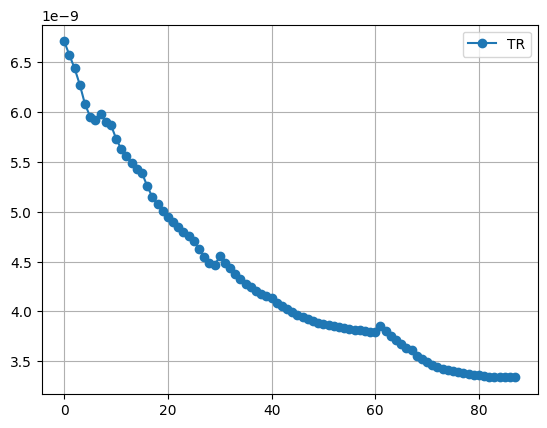

In [85]:
#plt.plot(data['FOM']['J'], marker='o', label='FOM')

TR_Js = []
inner_loop_statistics = data['TR']['inner_loop_statistics']
for inner_loop_statistic in inner_loop_statistics:
    TR_Js += inner_loop_statistic['J']

plt.plot(TR_Js, marker='o', label='TR')
plt.legend()
plt.grid()

In [86]:
inner_loop_statistics = data['TR']['inner_loop_statistics']
for inner_loop_statistic in inner_loop_statistics:
    print(inner_loop_statistic['J'])

[6.706834715505697e-09, 6.5687706019492714e-09, 6.4363694107183425e-09, 6.272880178700686e-09, 6.07814428900222e-09, 5.952495867974545e-09, 5.92377264825427e-09]
[5.981469970912474e-09, 5.895724889718566e-09, 5.8699213607549655e-09, 5.73310084282445e-09, 5.625975288000131e-09, 5.557147921405853e-09, 5.4901150156836316e-09, 5.424908771302016e-09, 5.386101076944618e-09, 5.258394447973206e-09, 5.145318028725678e-09, 5.072479507593154e-09, 5.005742181573258e-09, 4.943340917569584e-09, 4.8923680163930215e-09, 4.8434585676072115e-09, 4.796649936127846e-09, 4.751988837365611e-09, 4.709536023681242e-09, 4.620908130585375e-09, 4.545861183500607e-09, 4.48617304279456e-09, 4.463058903760594e-09]
[4.551164435275919e-09, 4.488200656656063e-09, 4.431402622245041e-09, 4.37114303441991e-09, 4.322086919781249e-09, 4.278963946389596e-09, 4.2411206997855825e-09, 4.207860246926822e-09, 4.178534910664559e-09, 4.152585025845748e-09, 4.129544522504698e-09, 4.088177932970444e-09, 4.052811048926567e-09, 4.0208

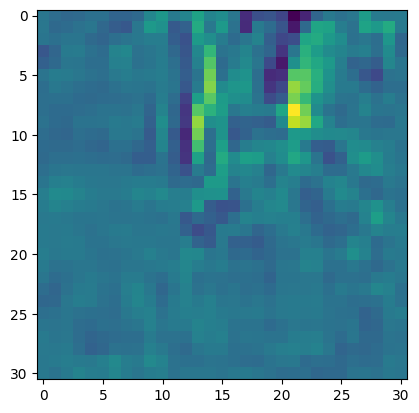

In [87]:
plt.imshow(data['TR']['q'][-1].to_numpy().reshape((31,31)))

(array([  3.,  13.,  42., 503., 324.,  48.,  12.,  10.,   4.,   2.]),
 array([0.92584924, 0.94495012, 0.96405099, 0.98315187, 1.00225275,
        1.02135363, 1.04045451, 1.05955538, 1.07865626, 1.09775714,
        1.11685802]),
 <BarContainer object of 10 artists>)

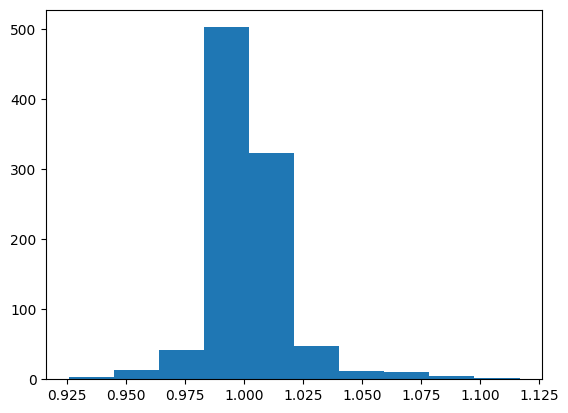

In [81]:
plt.hist(data['TR']['q'][-1].to_numpy().flatten())

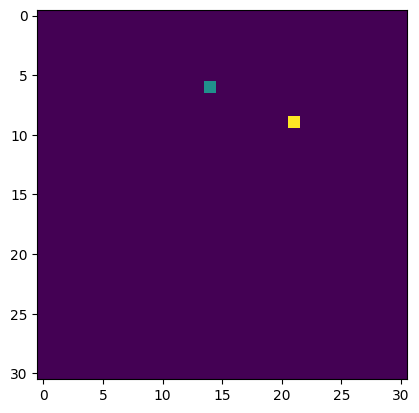

In [89]:
plt.imshow(setup['q_exact'].reshape((31,31)))

In [40]:
data['TR']['rel_est_error_nabla_J_r']

[nan, nan, nan, nan]

In [11]:
data['TR']['J']

[6.706834566982598e-09, 5.423277401771439e-09]

In [12]:
data['TR']['total_runtime']

[170.27885965799942]

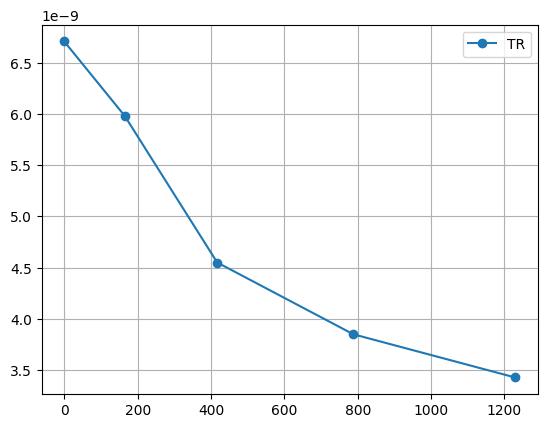

In [90]:
#FOM_time = np.array([0])
#FOM_time = np.append(FOM_time, data['FOM']['total_runtime'])

TR_time = np.array([0])
TR_time = np.append(TR_time, data['TR']['total_runtime'])

#plt.plot(FOM_time, data['FOM']['J'][:-1], marker='o', label='FOM')
plt.plot(TR_time, data['TR']['J'], marker='o', label='TR')
plt.legend()
plt.grid()

In [41]:
FOM_time[-1] / TR_time[-1]

NameError: name 'FOM_time' is not defined

In [42]:
TR_time

array([   0.        ,  188.89727553,  486.29795808,  842.46768382,
       1260.82127724, 1737.03828066])

In [131]:
FOM_time

array([   0.        ,  286.73681369,  412.653878  ,  542.1680552 ,
        678.48012487,  800.72643238,  928.17440918, 1046.38119216,
       1160.081659  , 1275.51755334, 1419.85074105, 1535.00839581,
       1834.80455998, 2005.2136992 , 2162.54972852, 2316.64443026,
       2457.85350005, 2609.05012862, 2760.94324533, 3118.59351414,
       3316.30827232, 3497.64769455, 3692.36166677, 3868.06627853,
       4044.71985879, 4523.12974749, 4807.59496986, 5034.95267434,
       5361.10657489, 5574.00893911])